In [114]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import pandas as pd


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);

In [115]:
# --- Simulation config ---
T_HORIZON = 3600.0          # [s]  total simulation horizon
T = 1000           # number of time steps
DT = T_HORIZON / (T)   # fixed for all sims
t_fixed = np.linspace(0, T_HORIZON, T)    # fixed 'physical' grid

In [116]:
# --- Data generation ---

translator = {
    'I': 'Current [A]',
    'V': 'Terminal voltage [V]',
    'cn': 'X-averaged negative particle concentration [mol.m-3]',
    'cp': 'X-averaged positive particle concentration [mol.m-3]',
    'cns': 'X-averaged negative particle surface concentration [mol.m-3]',
    'cps': 'X-averaged positive particle surface concentration [mol.m-3]',
    'ocv': 'Battery open-circuit voltage [V]',
}

translator_inv = {v: k for k, v in translator.items()}

data_cols = ['I', 'V', 'ocv']

def gen_cols(data_cols, translator=translator):
    '''Extracting variable names from translator dict for given data_cols'''
    return [translator[col] for col in data_cols]



def time_query(sol, t_fixed):
    t_end = sol["Time [s]"].entries[-1]
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    return t_query, valid

# def observe_states(t_query, sol, model, cols):
#     cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t_query)[-1, :]
#     cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t_query)[-1, :]
#     I = sol.observe(model.variables["Current [A]"])(t_query)
#     V = sol.observe(model.variables["Terminal voltage [V]"])(t_query)
#     return cn, cp, I, V

def observe_states(t_query, sol, model, data_cols):
    data = pd.DataFrame(index=t_query)
    cols = gen_cols(data_cols)
    for col in cols:
        data[translator_inv[col]] = sol.observe(model.variables[col])(t_query)
    return data

def get_vals_DC(I0,data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_DC1(I0, T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_pulse(data_cols=data_cols):
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(T_HORIZON, DT, RNG=None)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_GRF(data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_GRF(T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model


def gen_data(B, data_cols, currents='DC', I_low=0.25, I_high=1.0, seed=None):
    '''Generate trajectories with shape (B, T, D)'''

    rng = np.random.default_rng(seed)

    dot_cols = [f"{k}_dot" for k in data_cols if k in ['cn','cp']]
    all_cols = data_cols + ['dI'] + dot_cols + ['valid']

    D = len(all_cols)

    X = np.zeros((B, T, D))
    var_index = {k:i for i,k in enumerate(all_cols)}

    for b in trange(B):

        if currents == 'DC':
            data, valid_b, param, sol, model = get_vals_DC(float(rng.uniform(I_low, I_high)))
        elif currents == 'pulse':
            data, valid_b, param, sol, model = get_vals_pulse()
        elif currents == 'GRF':
            data, valid_b, param, sol, model = get_vals_GRF()
        else:
            raise ValueError("Invalid current type")

        # base variables
        for col in data_cols:
            X[b, :, var_index[col]] = data[col].values

        # dI
        if 'I' in data_cols:
            I = data['I'].values
            dI = np.zeros_like(I)
            dI[1:] = np.diff(I)
            X[b, :, var_index['dI']] = dI

        # derivatives
        for col in ['cn','cp']:
            if col in data_cols:
                x = data[col].values
                xdot = np.zeros_like(x)
                xdot[:-1] = np.diff(x) / DT
                xdot[-1] = xdot[-2]
                X[b, :, var_index[f"{col}_dot"]] = xdot

        # valid mask
        X[b, :, var_index['valid']] = valid_b.astype(float)

    return X, var_index


In [117]:
X, var_index = gen_data(2, data_cols, currents='DC', I_low=0.25, I_high=1.0, seed=42)
print("Data shape:", X.shape)
print("Variable index:", var_index)

100%|██████████| 2/2 [00:02<00:00,  1.35s/it]

Data shape: (2, 1000, 5)
Variable index: {'I': 0, 'V': 1, 'ocv': 2, 'dI': 3, 'valid': 4}


In [118]:
# --- Save data ---
# B_gen = 100
# dataX, var_index  = gen_data(B_gen, data_cols, currents='DC', I_low=0.25, I_high=1.0)
# np.savez(f'data_PHNN/data_c_DC_dt_{T}.npz', X=dataX, var_index=var_index)


In [131]:
# --- Load data ---
def load_data(path, var_index = var_index):
    with np.load(path) as d:
        X = d['X']  # replace 'X' with the actual key if different

    data = {var: X[:, :, idx] for var, idx in var_index.items()}
    return data


path = f'data_PHNN/data_c_DC_dt_{T}.npz'
D = load_data(path)
I = D['I']; V = D['V']; ocv = D['ocv']; valid = D['valid']
B = I.shape[0]

D['valid'] = D['valid'].astype(bool)


In [130]:
# --- Normalization ---
stats = {}
def compute_stats(D=D,data_cols=data_cols):
    for name in data_cols:
        stats[name] = (float(D[name].ravel()[D['valid'].ravel()].mean()), float(max(D[name].ravel()[D['valid'].ravel()].std(), 1e-8)))  # Avoid zero std
    return stats

def transform(arr, name):
    mean, std = stats[name]
    return (arr - mean) / std

def inverse_transform(arr, name):
    mean, std = stats[name]
    return arr * std + mean
    
stats = compute_stats()

# Normalize

I_n = I # transform(I, 'I')
V_n = transform(V, 'V')
ocv_n = transform(ocv, 'ocv')

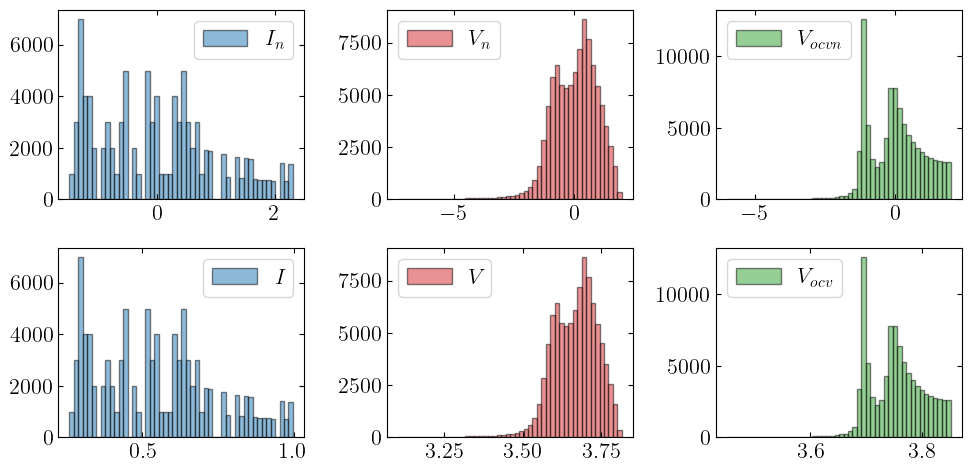

In [128]:
f,ax = plt.subplots(2,3, figsize=(10,5))
bins = 50; alpha = 0.5
plot_colors = ['tab:blue', 'tab:red','tab:green','black']
ax[0,0].hist(I_n.ravel()[D['valid'].ravel()], label=r'$I_n$',bins = bins, color=plot_colors[0], alpha=alpha, edgecolor='black')
ax[0,1].hist(V_n.ravel()[D['valid'].ravel()], label=r'$V_n$',bins = bins, color=plot_colors[1], alpha=alpha, edgecolor='black')
ax[0,2].hist(ocv_n.ravel()[D['valid'].ravel()], label=r'$V_{ocvn}$',bins = bins, color=plot_colors[2], alpha=alpha, edgecolor='black')
ax[1,0].hist(I.ravel()[D['valid'].ravel()], label=r'$I$',bins = bins, color=plot_colors[0], alpha=alpha, edgecolor='black')
ax[1,1].hist(V.ravel()[D['valid'].ravel()], label=r'$V$',bins = bins, color=plot_colors[1], alpha=alpha, edgecolor='black')
ax[1,2].hist(ocv.ravel()[D['valid'].ravel()], label=r'$V_{ocv}$',bins = bins, color=plot_colors[2], alpha=alpha, edgecolor='black')
for i in range(2):
    for j in range(3):
        ax[i,j].legend()
plt.tight_layout()

In [143]:
# --- Split data ---
x = torch.tensor(np.concatenate([I_n], axis=-1), dtype=torch.float32) # (B, T, 4)
y = torch.tensor(np.concatenate([V_n, ocv_n], axis=-1), dtype=torch.float32)
mask = torch.tensor(D['valid'], dtype=torch.float32)

split = int(0.8 * B)
print(split)
def _split(arr):
    return arr[:split], arr[split:]

def _split_flat(arr):
    return arr[:split].flatten(0,1), arr[split:].flatten(0,1)   # Same as reshape(B * T, C)    # (B*T, 4)

# Flatten time dimension for training and split
x_train, x_test = _split_flat(x)        
y_train, y_test = _split_flat(y)
mask_train, mask_test = _split_flat(mask)

# # Unflattened
x_train_batch, x_test_batch = _split(x) # (B, T, 4)
y_train_batch, y_test_batch = _split(y)
mask_train_batch, mask_test_batch = _split(mask)

# Un-normalized for plotting

I_train,      I_test      = _split(I)
V_train,      V_test      = _split(V)
ocv_train,    ocv_test    = _split(ocv)
mask_train_plot, mask_test_plot = _split(valid)

print('Shapes:', x_train.shape, y_train.shape, mask_train.shape, I_test.shape, V_test.shape, ocv_test.shape)

batch_size_small = int(B/4)
batch_size_large = int(B*T/4)
#train_loader_batch = DataLoader(TensorDataset(x_train_batch, y_train_batch, mask_train_batch), batch_size=batch_size_small, shuffle=True)
train_loader_flat = DataLoader(TensorDataset(x_train, y_train, mask_train), batch_size=batch_size_large, shuffle=True)

80
Shapes: torch.Size([80000]) torch.Size([160000]) torch.Size([80000]) (20, 1000) (20, 1000) (20, 1000)


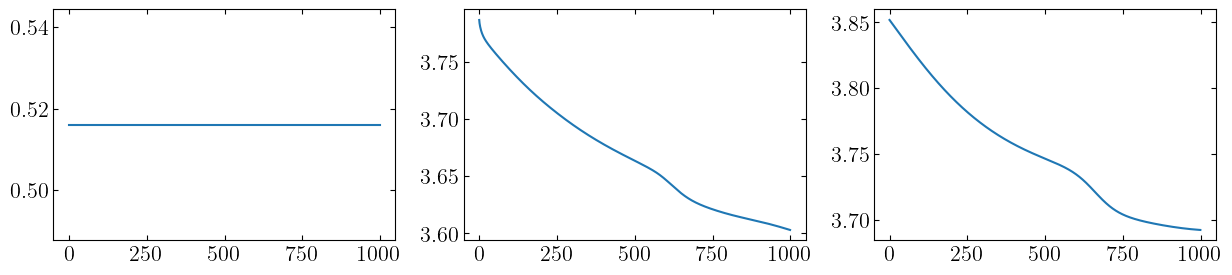

In [144]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(I_test[0, :], label='cn')
axes[1].plot(V_test[0, :], label='valid')
axes[2].plot(ocv_test[0, :], label='dI')


In [145]:
# --- Model ---
class Net(nn.Module):
    def __init__(self, input_size=1, hidden_size=128): #[I_t, C_nt, C_pt]
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 3)   # [G, z_1, z_2, m_1, m_2]
        )
    
    def forward(self, x):
        x = self.net(x)
        return x
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [11]:
# summary(model=model, input_size=(batch_size_small*T, 4))

In [ ]:
states = torch.zeros((T*batch_size_large, 2)) 

In [ ]:
# --- Training ---
def masked_mse(pred, target, mask):
    err = (pred - target) ** 2    # (B*T, 2)
    m = mask.unsqueeze(-1)        # (B*T, 1)
    return (err * m).sum() / (m.sum() * 2)


def ECM_dynamics(pred, states, I):
    R0 = pred[:, 0]  # (B*T,)
    C1 = pred[:, 1]  # (B*T,)
    R1 = pred[:, 2]  # (B*T,)

    q = states[:, 0] 
    Q = states[:, 1]  

    dq_dt = I - q / (R1 * C1)
    dQ_dt = -I
    return torch.stack([dq_dt, dQ_dt], dim=-1)  # (B*T, 2)

def evolver(pred, states,I,dt = DT):
    y0 = states + ECM_dynamics(pred, states, I) * dt
    eps = float('inf')
    R1 = pred[:, 2]  # (B*T,)
    C1 = pred[:, 1]  # (B*T,)
    while eps > 1e-3:
        y1 = y0 - np.linalg.inv(np.eye(len(y0)) - dt *  np.array([[- 1 / (R1 * C1), 0],[0 , 0]])) @ (y0 - states - ECM_dynamics(pred, y0, I) * dt)
        eps = torch.norm(y1 - y0)
        y0 = y1
    new_states = y1
    return new_states



def training(epochs=30):
    history = {"loss": [], "d_loss": [], "p_loss": [], "time per ep": []}
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        start_t = time.perf_counter()

        for x_b, y_b, mask_b in train_loader_flat:
            # x_b = x_b.requires_grad_()  # Enable gradients for input
            pred = model(x_b)   # [B*T, 2]

            optimizer.zero_grad()
            
            
            d_loss = mse_dot(pred, y_b, x_b)

            d_loss.backward()
            
            optimizer.step()
            tot_ep_loss += d_loss.item()

        avg_loss = tot_ep_loss / len(train_loader_flat)  # Average loss per batch
        end_t = time.perf_counter()

        history["loss"].append(avg_loss)
        #history["p_loss"].append(p_last)
        history["time per ep"].append(end_t - start_t)
        print(f"Epoch {ep+1} | loss {avg_loss:.3e} | time {end_t - start_t:.2f}s")

    return history





history = training(epochs=100)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x25000 and 1x128)

In [79]:
Euler_exp_log.exp_log(model, history, name = 'Data dt=0.1', d_loss_type = 'mse')

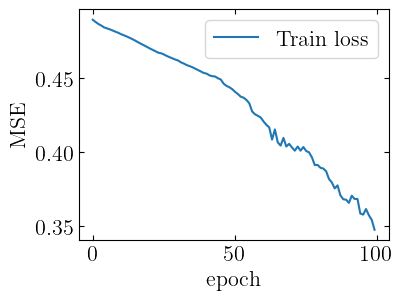

In [23]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.plot(history["loss"], label="Train loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend();

In [ ]:
# --- Euler rollout ---
def rollout(idx=0, dt_eval=DT, on_train=False):
    if on_train:
        cn_true = cn_train
        cp_true = cp_train
        I_true = I_train
        dI_true = dI_train
    else:
        cn_true = cn_test
        cp_true = cp_test
        I_true = I_test
        dI_true = dI_test

    model.eval()

    # Original time grid (training resolution)
    t_train = np.arange(T) * DT

    # Interpolate I and dI onto the new dt grid
    def I_t(t):  
        return float(np.interp(t, t_train, I_true[idx, :, 0]))  # Value at time t
    def dI_t(t): 
        return float(np.interp(t, t_train, dI_true[idx, :, 0]))

    # Pre-allocate generously
    max_steps = int(T_HORIZON / dt_eval)
    cn_traj = np.zeros(max_steps, dtype=np.float32)
    cp_traj = np.zeros(max_steps, dtype=np.float32)
    cn_dot_traj = np.zeros(max_steps, dtype=np.float32)
    cp_dot_traj = np.zeros(max_steps, dtype=np.float32)
    cn_traj[0] = cn_true[idx, 0, 0]     # Initial un-normalized values for the chosen trajectory
    cp_traj[0] = cp_true[idx, 0, 0]
    
    steps_run = 1
    step = 0
    with torch.no_grad():
        # Rollout until depletion
        while cn_traj[steps_run-1] >= cn_true[idx].min() and steps_run < max_steps:
            t_now = step * dt_eval

            x_t = np.array([[
                transform(np.array([[[I_t(t_now)]]]),  "I")[0,0,0],  # True
                transform(np.array([[[cn_traj[step]]]]), "cn")[0,0,0],     # Predicted
                transform(np.array([[[cp_traj[step]]]]), "cp")[0,0,0],]], dtype=np.float32)      # Predicted                  # (1, 4)

            # Predict on initial state (1, 4)
            pred = model(torch.tensor(x_t))              # (1, 2)
            dc_n = inverse_transform(pred[0,0].numpy().reshape(1,1,1), "cn_dot")[0,0,0]
            dc_p = inverse_transform(pred[0,1].numpy().reshape(1,1,1), "cp_dot")[0,0,0]

            cn_traj[step+1] = cn_traj[step] + dc_n * dt_eval
            cp_traj[step+1] = cp_traj[step] + dc_p * dt_eval
            cn_dot_traj[step] = dc_n
            cp_dot_traj[step] = dc_p

            steps_run += 1
            step += 1

    # TODO: Trim to actual length ?
    return cn_traj, cp_traj, cn_dot_traj, cp_dot_traj, steps_run

In [140]:


# --- Plot rollout ---
def plot_rollout(cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run, 
                 idx=0, dt_eval=DT, on_train=False):
    if on_train:
        cn_true = cn_train
        cp_true = cp_train
        cn_dot_true = cn_dot_train
        I_true = I_train
        dI_true = dI_train
    else:
        cn_true = cn_test
        cp_true = cp_test
        cn_dot_true = cn_dot_test
        I_true = I_test
        dI_true = dI_test


    # Ground truth valid length
    n_gt = int(mask_train_plot[idx].sum())          # number of valid GT steps
    n_nn = steps_run                          # number of NN steps before stopping
    t_gt = np.arange(n_gt) * DT             # physical time axis for GT
    t_nn = np.arange(n_nn) * dt_eval             # physical time axis at new resolution
    

    fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))

    cn_err = (cn_true[idx, :n_nn, 0] - cn_euler[:n_nn]) / (cn_true[idx, :n_nn, 0])

    # --- cn err ---
    axes[0].bar(t_nn, cn_err, color="tab:blue")
    axes[0].set_xlabel("Time [s]")
    axes[0].set_ylabel("Relative error in $c_n$ [a.u.]")

    # --- cn ---
    axes[1].plot(t_gt, cn_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $c_n$")
    axes[1].plot(t_nn, cn_euler[:n_nn], color="tab:blue", label="Predicted $c_n$")
    axes[1].set_xlabel("Time [s]")
    axes[1].set_ylabel(r"Concentration [mol/m$^3$]")
    axes[1].legend()

    # --- cp ---
    axes[2].plot(t_gt, cp_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $c_p$")
    axes[2].plot(t_nn, cp_euler[:n_nn], color="tab:blue", label="Predicted $c_p$")
    axes[2].set_xlabel("Time [s]")
    axes[2].set_ylabel(r"Concentration [mol/m$^3$]")
    axes[2].legend()

    # --- cn_dot ---
    axes[3].plot(t_gt, cn_dot_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $\\dot{c}_n$")
    axes[3].plot(t_nn, cn_dot_euler[:n_nn], color="tab:blue", label="Predicted $\\dot{c}_n$")
    axes[3].set_xlabel("Time [s]")
    axes[3].set_ylabel(r"Concentration rate [mol/m$^3$/s]")
    axes[3].legend()
    
    # --- current ---
    axes[4].plot(t_gt, I_train[idx, :n_gt, 0], color="black", label="$I$")
    axes[4].set_xlabel("Time [s]")
    axes[4].set_ylabel("Current [A]")
    axes[4].legend(loc='upper right')


    # --- dI ---
    axes3_ = axes[4].twinx()
    axes3_.plot(t_gt, dI_train[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="$\\dot{I}$")
    axes3_.set_ylabel(r"Current rate [A/s]")
    axes3_.legend(loc='upper left')

    plt.tight_layout()
    # plt.savefig('figs/5.1_predict_ep50_GRF.pdf')
    return t_gt, t_nn, n_gt, n_nn

In [111]:
idx = 0
dt_eval = 0.5
on_train = False
cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run = rollout(idx, dt_eval, on_train)

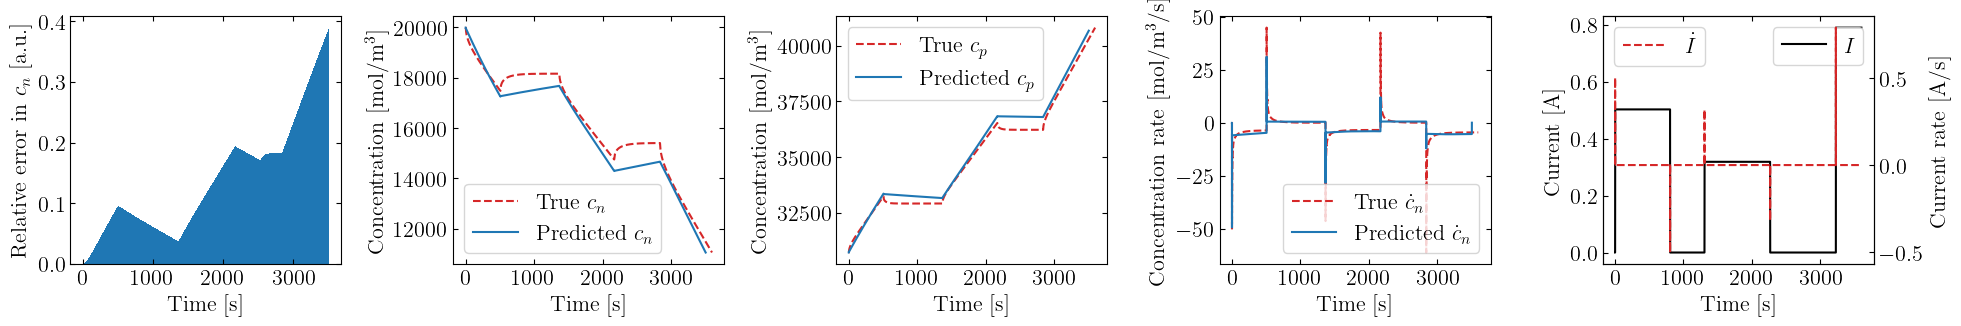

In [141]:
t_gt, t_nn, n_gt, n_nn = plot_rollout(cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run, idx, dt_eval, on_train)

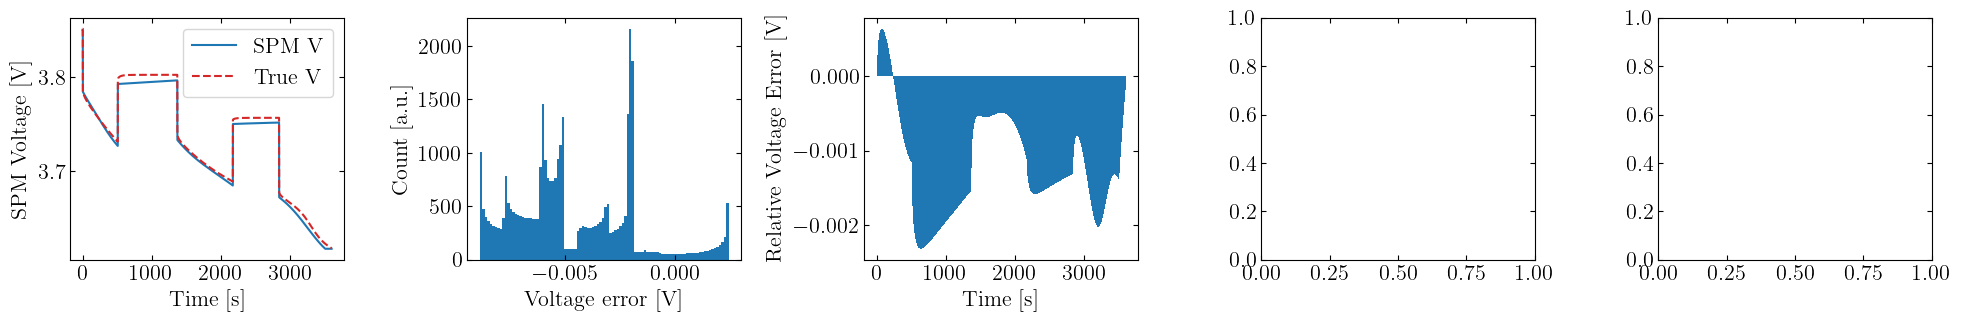

In [146]:
# --- Reconstruct voltage ---
# Interpolate rollout concentrations onto the GT time grid
cn_euler_gt = np.interp(t_gt, t_nn, cn_euler[:n_nn])
cp_euler_gt = np.interp(t_gt, t_nn, cp_euler[:n_nn])

V_spm = SPM_eqs.V_terminal(I_test[idx, :n_gt, 0], cp_euler_gt, cn_euler_gt, param)
V_true = V_test[idx, :n_gt, 0]

# I_nn    = np.interp(t_nn, t_gt, I_test[idx, :n_gt, 0])
# V_true_nn = np.interp(t_nn, t_gt, V_test[idx, :n_gt, 0])

# V_spm = SPM_eqs.V_terminal(I_nn, cp_euler[:n_nn], cn_euler[:n_nn], param)

ocv = SPM_eqs.OCV(cn_test[idx, :n_gt, 0], cp_test[idx, :n_gt, 0])

err = V_spm - V_true
err = err[np.isfinite(err)]

fig , axes = plt.subplots(1, 5, figsize=(20, 3.5))
axes[0].plot(t_gt, V_spm, label='SPM V')
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("SPM Voltage [V]")
axes[0].plot(t_gt, V_true, label='True V', linestyle="dashed", color="tab:red")
axes[0].legend()
axes[1].hist(err, bins=100, label='True V')
axes[1].set_xlabel("Voltage error [V]")
axes[1].set_ylabel("Count [a.u.]")
axes[2].bar(t_gt, err / np.max(np.abs(V_true)), label='OCV')
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Relative Voltage Error [V]")

plt.tight_layout()
# plt.savefig('figs/5.1_SPM_V_ep100.pdf')